# Lab 05: The Dark Companion, Two Years Later

**ASTR 457, Fall 2026, posted Sat Oct 3, due Fri Oct 9 by Noon (extended) (fork → PR, as always)**

*Why this lab: every orbit in the literature, from Gaia's black-hole binaries to the planets David Charbonneau talked about on Tuesday, is a posterior distribution over six or seven parameters that nobody can write down in closed form. Sampling it, knowing when the sampler has actually converged, and turning the samples into a number with an honest error bar is the core professional skill of modern astrophysics, and the place where confident, fluent, wrong analyses are most common.*

On Day 1 you watched a star's radial velocity drift over ten nights and inferred an unseen companion from
the slope alone. This is that programme, two and a half years on. Every one of you has your own star:
`data/<your netid>.csv`, with columns `t_days` (time of each spectrum, from the first epoch), `rv_kms`
(the measured radial velocity) and `sigma_rv_kms` (the pipeline's per-epoch uncertainty). The star was
observed in three observing seasons over about 900 days, 28 to 44 epochs in all. It is a **single-lined
spectroscopic binary**: you see one star's lines, the companion contributes no light, and the visible star
follows a Keplerian orbit,

$$v_r(t) = \gamma + K\left[\cos\big(\nu(t) + \omega\big) + e\cos\omega\right],$$

with period $P$, semi-amplitude $K$, eccentricity $e$, argument of periastron $\omega$, a time of periastron
$T_p$, systemic velocity $\gamma$, and $\nu(t)$ the true anomaly (the angle around the orbit, which you get
from Kepler's equation; a function is provided). What you are really after is the **mass function**

$$f(M) = \frac{P K^3 (1 - e^2)^{3/2}}{2\pi G} = \frac{M_2^3 \sin^3 i}{(M_1 + M_2)^2},$$

a lower limit on the companion's mass, in solar masses. If it comes out above about $3\,M_\odot$ for a
Sun-like primary, you have a black hole candidate, the way Gaia BH1 was found (El-Badry et al. 2023, the Sep 8
colloquium). In the units of your file, $f(M) = 1.0361\times10^{-7}\,(1-e^2)^{3/2} K^3 P$ with $K$ in km/s
and $P$ in days.

I know your true $P$, $K$, $e$ and $f(M)$. You don't, your classmates' stars are different, and so is the
sampling. **One more thing I know and you don't: the quoted `sigma_rv_kms` is not the whole error.** Real
radial velocities carry an extra scatter, called jitter, from the star's own surface and from template
mismatch, and it is not in the pipeline number.

**How this is graded.** As always, on whether your answers are *right* and your uncertainties are *honest*:
your reported $P$, $K$, $e$ and $f(M)$ are compared to your truth in units of your own reported uncertainty.
Anti-sandbagging cap: your $\sigma_K$ may not exceed $3\times$ a reference posterior width I compute for your
dataset. Padded error bars lose points like overconfident ones.

**AI policy reminder.** Use whatever tools you like, including AI assistants, and document it in Part 4. You
may be selected to defend this lab orally; the defense is easy if you did the work.

Weights: Part 1 15%, Part 2 40%, Part 3 35%, Part 4 10%.


In [141]:
import numpy as np
import matplotlib.pyplot as plt
import emcee
import corner
from scipy.optimize import minimize
from astropy.timeseries import LombScargle

NETID = 'saumyap2'   # <-- set this
d = np.genfromtxt(f'../../labs/05/data/{NETID}.csv', delimiter=',', names=True)
t, rv, sig = d['t_days'], d['rv_kms'], d['sigma_rv_kms']
print(f"{t.size} epochs over {t.max() - t.min():.0f} days; median quoted error {np.median(sig):.2f} km/s")

def kepler_rv(t, P, K, e, omega, Tp, gamma):
    """Radial velocity of the visible star in a Keplerian orbit.
    P period [d], K semi-amplitude [km/s], e eccentricity, omega argument of periastron [rad],
    Tp a time of periastron [d], gamma systemic velocity [km/s]. Solves Kepler's equation by Newton iteration."""
    M = 2. * np.pi * ((t - Tp) / P % 1.0)            # mean anomaly
    E = M.copy()                                     # eccentric anomaly
    for _ in range(30):
        E = E - (E - e * np.sin(E) - M) / (1. - e * np.cos(E))
    nu = 2. * np.arctan2(np.sqrt(1. + e) * np.sin(E / 2.), np.sqrt(1. - e) * np.cos(E / 2.))   # true anomaly
    return gamma + K * (np.cos(nu + omega) + e * np.cos(omega))

def mass_function(P, K, e):
    """f(M) in solar masses, for P in days and K in km/s."""
    return 1.0361e-7 * (1. - e**2)**1.5 * K**3 * P

30 epochs over 890 days; median quoted error 1.59 km/s


## Part 1: Look first, then find the period (15%)

Plot the radial velocities against time with their error bars. Then find candidate orbital periods with a
Lomb-Scargle periodogram of the velocities (`astropy.timeseries.LombScargle`, Day 7's periodogram, formally
taught on Oct 20/22; for now it is a tool that ranks periods). Plot the periodogram. Then, for the best two or
three candidate periods, phase-fold the data and look.

Answer, in a few sentences: how many candidate periods are plausible from the periodogram alone, and why does
a Lomb-Scargle periodogram (which fits a *sinusoid*) not settle the question for an eccentric orbit? What
feature of the sampling (look at the gaps) produces the other peaks?


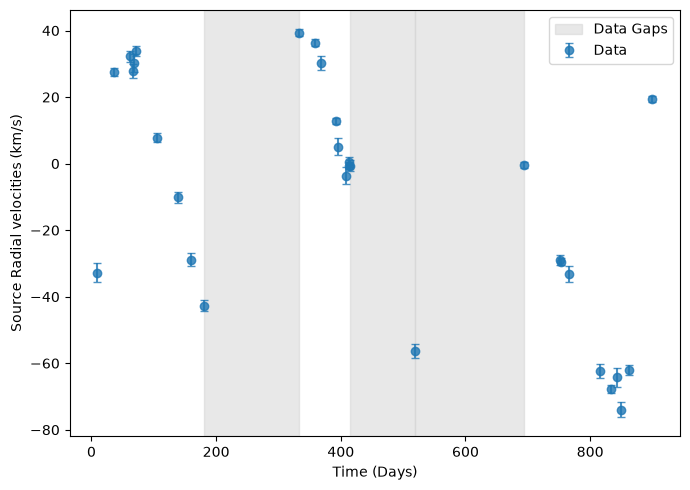

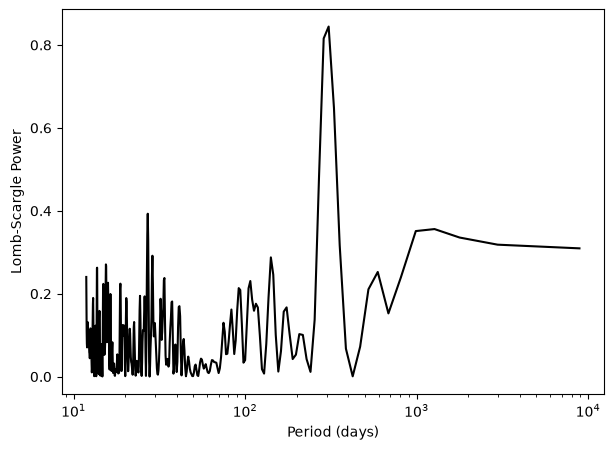

Top candidate periods:
P = 306.934 d, power = 0.845
P = 287.132 d, power = 0.816
P = 329.670 d, power = 0.648


In [142]:
# Part 1: your work here


plt.figure(figsize=(7, 5))
plt.errorbar(
    t, rv,
    yerr=sig,
    fmt='o',
    capsize=3,
    alpha=0.8,
    label='Data'
)

first_shade = False
for i in range(len(t)-1):
    if t[i+1] - t[i] >= 100:
        lbl = "Data Gaps" if not first_shade else None
        plt.axvspan(t[i], t[i+1], color='lightgray', alpha=0.5, label= lbl)
        first_shade = True


plt.xlabel(r'Time (Days)')
plt.ylabel(r'Source Radial velocities (km/s)')
plt.legend()
plt.tight_layout()
plt.show()

freq, power = ls(t, rv, sig).autopower()

period = 1/freq

plt.figure(figsize=(7,5))
plt.plot(period, power, color='k')
plt.xlabel('Period (days)')
plt.ylabel('Lomb-Scargle Power')
plt.xscale('log')
plt.show()

idx = np.argsort(power, descending=True)[:10]
print("Top candidate periods:")
for i in idx[:3]:
    print(f"P = {period[i]:.3f} d, power = {power[i]:.3f}")

**ANSWER (a few sentences):**

Based on the periodogram, I'd say that there are only ~3 plausible candidates as the dominant peak is sharp and much higher than the rest, though there are a few secondary peaks. The Lomb-Scargle does not settle this question because it fits a sinusoid and the radial velocity curve of a Keplerian orbit with eccentricity is usually not sinusoidal. An eccentric orbit looks quite different from a sinusoid sharp changes in velocity near periastron and asymmetries. As you can see in the data plot, The observing sessions are separated by long gaps of time so this is allows multiple periods to fit the sample. 

## Part 2: Sample the posterior (40%)

Fit the six orbital parameters **plus a jitter term** $s$ with `emcee`. The likelihood for epoch $i$ is
Gaussian with variance $\sigma_i^2 + s^2$; write it out (including the $\log$ of the variance, which is not a
constant once $s$ is a parameter). You will need to:

1. **Write the log-likelihood, log-prior and log-posterior.** State every prior and justify it in one line
   each. Two traps: $\omega$ and $T_p$ are periodic ($T_p$ is only defined modulo $P$), and `emcee` does not
   wrap angles, so a hard prior wall at $0$ or $2\pi$ can cut a posterior mode in half. Either bound each of
   them within half a period of your starting value, or reparameterize with $\sqrt{e}\cos\omega$ and
   $\sqrt{e}\sin\omega$ (which also gives a uniform prior on $e$ without a wall at zero). Jitter is
   positive: sample $\ln s$.
2. **Start the walkers sensibly.** A maximum-likelihood fit from each plausible Part 1 period, with several
   starting $\omega$ and $T_p$ each, then compare the log-likelihoods; start the walkers in a small ball
   around the best one. That comparison is the check: report the log-likelihood of the runner-up.
3. **Run, then decide when it is done.** Compute the integrated autocorrelation time $\tau$ for every
   parameter (`sampler.get_autocorr_time`). Here $\tau$ is about 50 to 100 steps, so 64 walkers for
   10,000 steps is plenty (a few minutes) and `emcee`'s own rule is a chain longer than $50\tau$. A
   common choice is to discard a few $\tau$ as burn-in and thin by about $\tau/2$; say what you chose
   and why. Plot the chains. If $\tau$ cannot be estimated, your chain is too short; say so and fix it.
4. **Corner plot.** Which parameters are correlated, and why physically?
5. **Report** $P$, $K$, $e$, $\gamma$, the jitter $s$, and $f(M)$, each as a median and 68% interval.
   **$f(M)$ is computed for every posterior sample**, not from the medians of $P$, $K$ and $e$; explain in
   one sentence why that matters.
6. **Posterior predictive check.** Draw a few hundred orbits from the posterior and plot them over the data,
   phase-folded at the median period. Plot the normalized residuals with the *total* error bar
   $\sqrt{\sigma_i^2 + s^2}$. Is what is left noise?

**FINAL ANSWER:** $P = $ ___ $\pm$ ___ d, $K = $ ___ $\pm$ ___ km/s, $e = $ ___ $\pm$ ___, $\gamma = $ ___ $\pm$ ___ km/s, jitter $s = $ ___ $\pm$ ___ km/s, $f(M) = $ ___ $\pm$ ___ $M_\odot$. Is your companion a black-hole candidate? One sentence.


1. Priors

$\ln(P)$ ∼($\ln 50$,$\ln 2000$): weakly informative log-uniform prior over periods consistent with the observed ∼900-day baseline.

K ∼(0,200 km/s): the radial velocity semi-amplitude must be positive, and 200 km/s comfortably exceeds the observed velocity range.

(h,k)=$(\sqrt e\cos\omega,\sqrt e\sin\omega)$ uniform inside the unit disk $h^2+k^2<1$: enforces $e<10≤e<1$ while avoiding boundaries at e=0 and $\omega =0,2\pi$.

Tp ∼(-2000,2000): The interval allows periastron times before the first observation and after it, rather than forcing Tp into the interval from zero to one period.

γ ∼(−200,200 km/s): broad prior on the systemic velocity that easily contains the observed RVs.

$\ln(s)$ ∼(−10,5): sampling $\ln(⁡s)$ guarantees positive jitter and allows the scale of the extra noise to vary over orders of magnitude.

In [143]:
# Part 2: your work here
# 2.1

def log_prior(theta):
    lnP, K, h, k, Tp, gamma, lns = theta

    e = h*h + k*k

    if not (np.log(50) < lnP < np.log(2000)):
        return -np.inf
    
    if not (0 < K < 200):
        return -np.inf
    
    if not (-200 < gamma < 200):
        return -np.inf
    
    if not (h**2 + k**2 < 1):
        return -np.inf
    
    if not (-10 < lns < 5):
        return -np.inf

    P = np.exp(lnP)

    if not (-2000 <= Tp < 2000):
        return -np.inf

    return 0.0


def log_likelihood(theta):
    lnP, K, h, k, Tp, gamma, lns = theta

    P = np.exp(lnP)
    e = h*h + k*k
    omega = np.arctan2(k, h)
    s = np.exp(lns)

    model = kepler_rv(t, P, K, e, omega, Tp, gamma)

    var = sig**2 + s**2

    return -0.5 * np.sum(
        (rv - model)**2 / var
        + np.log(2*np.pi*var)
    )


def log_posterior(theta):
    lp = log_prior(theta)

    if not np.isfinite(lp):
        return -np.inf

    return lp + log_likelihood(theta)

In [146]:
# Part 2.2

from scipy.optimize import minimize, least_squares

periods = [60, 150, 287.132, 306.934, 329.670]

def residuals(x):
    lnP, K, e, omega, Tp, gamma = x
    model = kepler_rv(t, np.exp(lnP), K, e, omega, Tp, gamma)
    return (rv - model) / sig

def to_theta(x):
    lnP, K, e, omega, Tp, gamma = x
    h = np.sqrt(e) * np.cos(omega)
    k = np.sqrt(e) * np.sin(omega)

    model = kepler_rv(t, np.exp(lnP), K, e, omega, Tp, gamma)
    s2 = max(np.mean((rv - model)**2 - sig**2), 1e-6)
    lns = np.log(np.sqrt(s2))

    return np.array([lnP, K, h, k, Tp, gamma, lns])

def objective(theta):
    if not np.isfinite(log_prior(theta)):
        return 1e100
    return -log_likelihood(theta)


In [148]:
results = []

lower = [np.log(50), 0.01, 0, -np.inf, -2000, -200]
upper = [np.log(2000), 199, 0.99, np.inf, 2000, 200]

for P0 in periods:
    fits = []

    for omega0 in np.linspace(0, 2*np.pi, 4, endpoint=False):
        for frac in np.linspace(0, 1, 4, endpoint=False):
            for e0 in [0.1, 0.5]:

                x0 = [
                    np.log(P0), 60, e0,
                    omega0, frac*P0, np.median(rv)
                ]

                sol = least_squares(
                    residuals, x0, bounds=(lower, upper),
                    max_nfev=2000
                )

                fits.append((np.sum(sol.fun**2), to_theta(sol.x)))

    fits.sort(key=lambda x: x[0])

    for _, theta0 in fits[:3]:
        sol = minimize(
            objective, theta0, method="Nelder-Mead",
            options={"maxiter": 10000}
        )

        theta = sol.x if objective(sol.x) < objective(theta0) else theta0
        results.append((log_likelihood(theta), P0, theta))

candidate_best = []

for P0 in periods:
    fits = [r for r in results if r[1] == P0]
    candidate_best.append(max(fits, key=lambda r: r[0]))

candidate_best.sort(key=lambda r: r[0], reverse=True)

print("Best fit originating from each candidate:")
for logL, P0, theta in candidate_best:
    print(f"start P = {P0:7.1f} d  "
          f"fit P = {np.exp(theta[0]):8.2f} d  "
          f"logL = {logL:9.3f}")

best_logL, best_startP, best_theta = candidate_best[0]

print("\nBest solution:")
print(f"Fitted period = {np.exp(best_theta[0]):.3f} d")
print(f"Log-likelihood = {best_logL:.3f}")

print("\nRunner-up starting-period candidate:")
print(f"Log-likelihood = {candidate_best[3][0]:.3f}")

P_ref = np.exp(best_theta[0])
Tp_ref = best_theta[4]

Tp_min = Tp_ref - P_ref/2
Tp_max = Tp_ref + P_ref/2

print(f"\nMCMC Tp bounds: {Tp_min:.2f} to {Tp_max:.2f}")


Best fit originating from each candidate:
start P =   329.7 d  fit P =   290.30 d  logL =   -78.100
start P =   287.1 d  fit P =   290.30 d  logL =   -78.100
start P =   306.9 d  fit P =   290.30 d  logL =   -78.100
start P =   150.0 d  fit P =   168.04 d  logL =  -137.548
start P =    60.0 d  fit P =    58.64 d  logL =  -147.654

Best solution:
Fitted period = 290.300 d
Log-likelihood = -78.100

Runner-up starting-period candidate:
Log-likelihood = -137.548

MCMC Tp bounds: 165.17 to 455.47



I performed maximum-likelihood fits starting from the plausible Lomb-Scargle periods (60, 150, and 330 d) and multiple initial values of $\omega$ and Tp. Best solution and runner up are shown above. The runner up likelihood is substantially worse than the best fit, so I initialized the MCMC walkers around the P≈290.30 days solution.

Starting walkers: (64, 7)
All walkers valid: True

Integrated autocorrelation times:
lnP  : tau = 71.7 steps
K    : tau = 75.8 steps
h    : tau = 77.4 steps
k    : tau = 70.3 steps
Tp   : tau = 75.3 steps
gamma: tau = 77.9 steps
lns  : tau = 81.3 steps

Total steps = 10000
50 * max(tau) = 4063.8
Convergence length criterion met: True

Mean acceptance fraction = 0.488
Minimum acceptance fraction = 0.473
Walkers with acceptance fraction < 0.2: []

Burn-in = 244 steps
Thinning = every 35 steps
Posterior sample shape: (17792, 7)


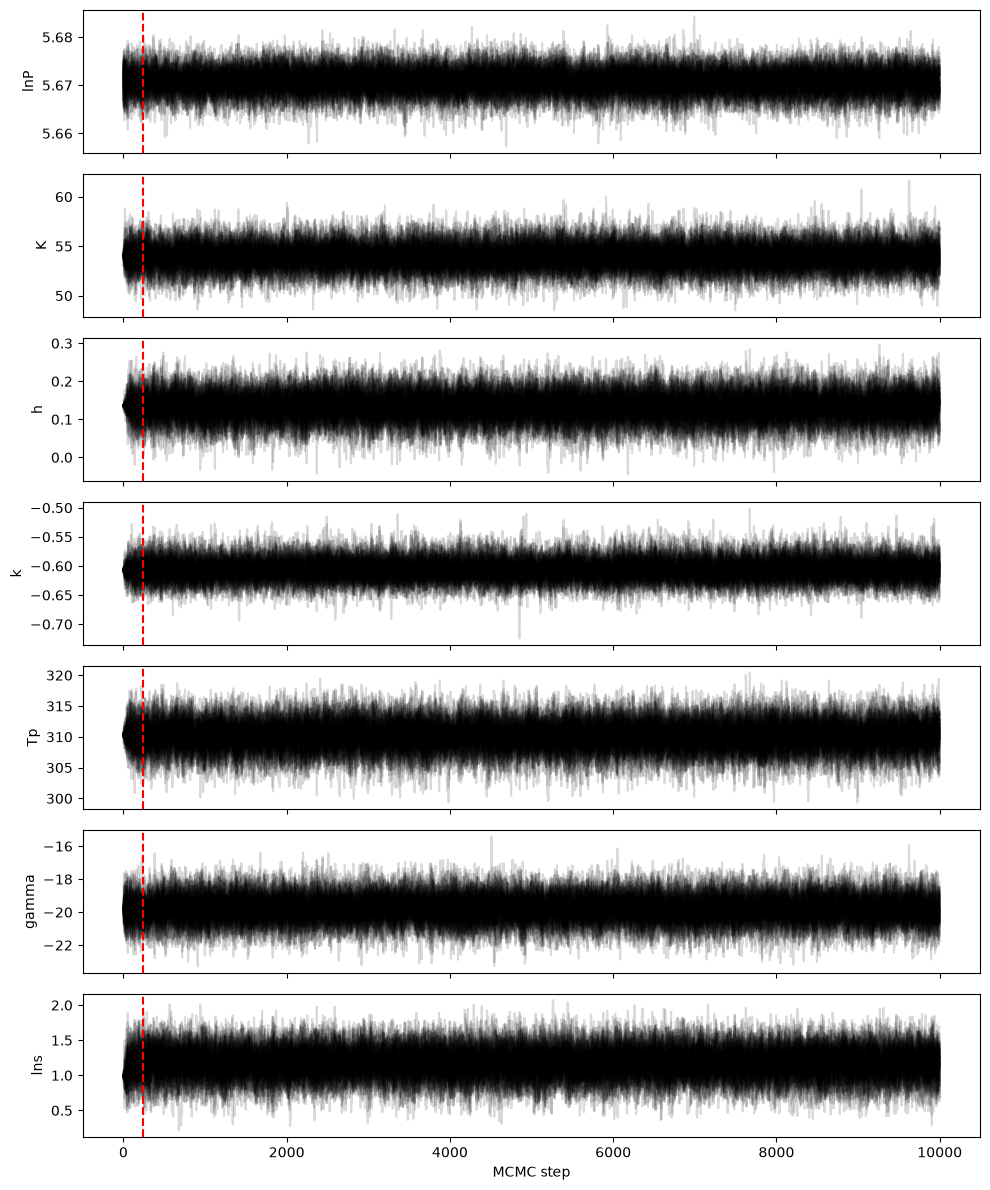

In [151]:
# Part 2.3
def log_prior(theta):
    lnP, K, h, k, Tp, gamma, lns = theta

    e = h*h + k*k

    if not (np.log(50) < lnP < np.log(2000)):
        return -np.inf
    
    if not (0 < K < 200):
        return -np.inf
    
    if not (-200 < gamma < 200):
        return -np.inf
    
    if not (h**2 + k**2 < 1):
        return -np.inf
    
    if not (-10 < lns < 5):
        return -np.inf

    P = np.exp(lnP)

    if not (Tp_min <= Tp < Tp_max):
        return -np.inf

    return 0.0
ndim = len(best_theta)
nwalkers = 64
nsteps = 10000

parameter_names = ["lnP", "K", "h", "k", "Tp", "gamma", "lns"]

walker_scale = np.array([
    1e-3, 0.1, 1e-3, 1e-3, 0.1, 0.1, 1e-2
])

pos = []
while len(pos) < nwalkers:
    trial = best_theta + walker_scale * np.random.randn(ndim)
    if np.isfinite(log_posterior(trial)):
        pos.append(trial)

pos = np.array(pos)

print("Starting walkers:", pos.shape)
print("All walkers valid:",
      all(np.isfinite(log_posterior(p)) for p in pos))

sampler = emcee.EnsembleSampler(nwalkers, ndim, log_posterior)
sampler.run_mcmc(pos, nsteps, progress=False)

while True:
    N = sampler.get_chain().shape[0]

    try:
        tau = sampler.get_autocorr_time()
        if N > 50 * np.max(tau):
            break
    except emcee.autocorr.AutocorrError:
        print(f"Chain too short at {N} steps.")

    if N >= 40000:
        raise RuntimeError("Convergence not established; inspect chains.")

    print("Extending chain by 5000 steps...")
    sampler.run_mcmc(None, 5000, progress=False)

print("\nIntegrated autocorrelation times:")
for name, value in zip(parameter_names, tau):
    print(f"{name:5s}: tau = {value:.1f} steps")

print(f"\nTotal steps = {N}")
print(f"50 * max(tau) = {50*np.max(tau):.1f}")
print("Convergence length criterion met:",
      N > 50*np.max(tau))

acceptance = sampler.acceptance_fraction
print(f"\nMean acceptance fraction = {np.mean(acceptance):.3f}")
print(f"Minimum acceptance fraction = {np.min(acceptance):.3f}")
print("Walkers with acceptance fraction < 0.2:",
      np.where(acceptance < 0.2)[0])

burnin = int(np.ceil(3 * np.max(tau)))
thin = max(1, int(np.floor(0.5 * np.min(tau))))

flat_samples = sampler.get_chain(
    discard=burnin, thin=thin, flat=True
)

print(f"\nBurn-in = {burnin} steps")
print(f"Thinning = every {thin} steps")
print("Posterior sample shape:", flat_samples.shape)

chain = sampler.get_chain()

fig, axes = plt.subplots(ndim, 1, figsize=(10, 12), sharex=True)

for j, name in enumerate(parameter_names):
    axes[j].plot(chain[:, :, j], color="black", alpha=0.15)
    axes[j].axvline(burnin, color="red", linestyle="--")
    axes[j].set_ylabel(name)

axes[-1].set_xlabel("MCMC step")
plt.tight_layout()
plt.show()


I ran emcee with 64 walkers for 10,000 steps, initializing them with small random perturbations around the best-fit solution from Part 2.2.

I computed the integrated autocorrelation times using sampler.get_autocorr_time(). They ranged from ~70.0 to 82 steps across the seven parameters. The maximum autocorrelation time gives 4063.8 steps, which is less than the total chain length of 10,000 steps, satisfying the convergence-length criterion.

I discarded the first 247 steps as burn-in, approximately three times the maximum autocorrelation time, to reduce dependence on the initial walker positions. I then thinned the chain by retaining every 35th step, approximately half the minimum autocorrelation time, to reduce correlations between retained samples. This resulted in 17,792 posterior samples.

The trace plots show that the walkers mix well and remain approximately stationary after burn-in, without any obvious separate or drifting chains. The mean acceptance fraction was 0.487, with a minimum of 0.467, indicating reasonably consistent acceptance rates across walkers.

Overall, the autocorrelation-time criterion, trace plots, and acceptance fractions support convergence within the sampled posterior mode.

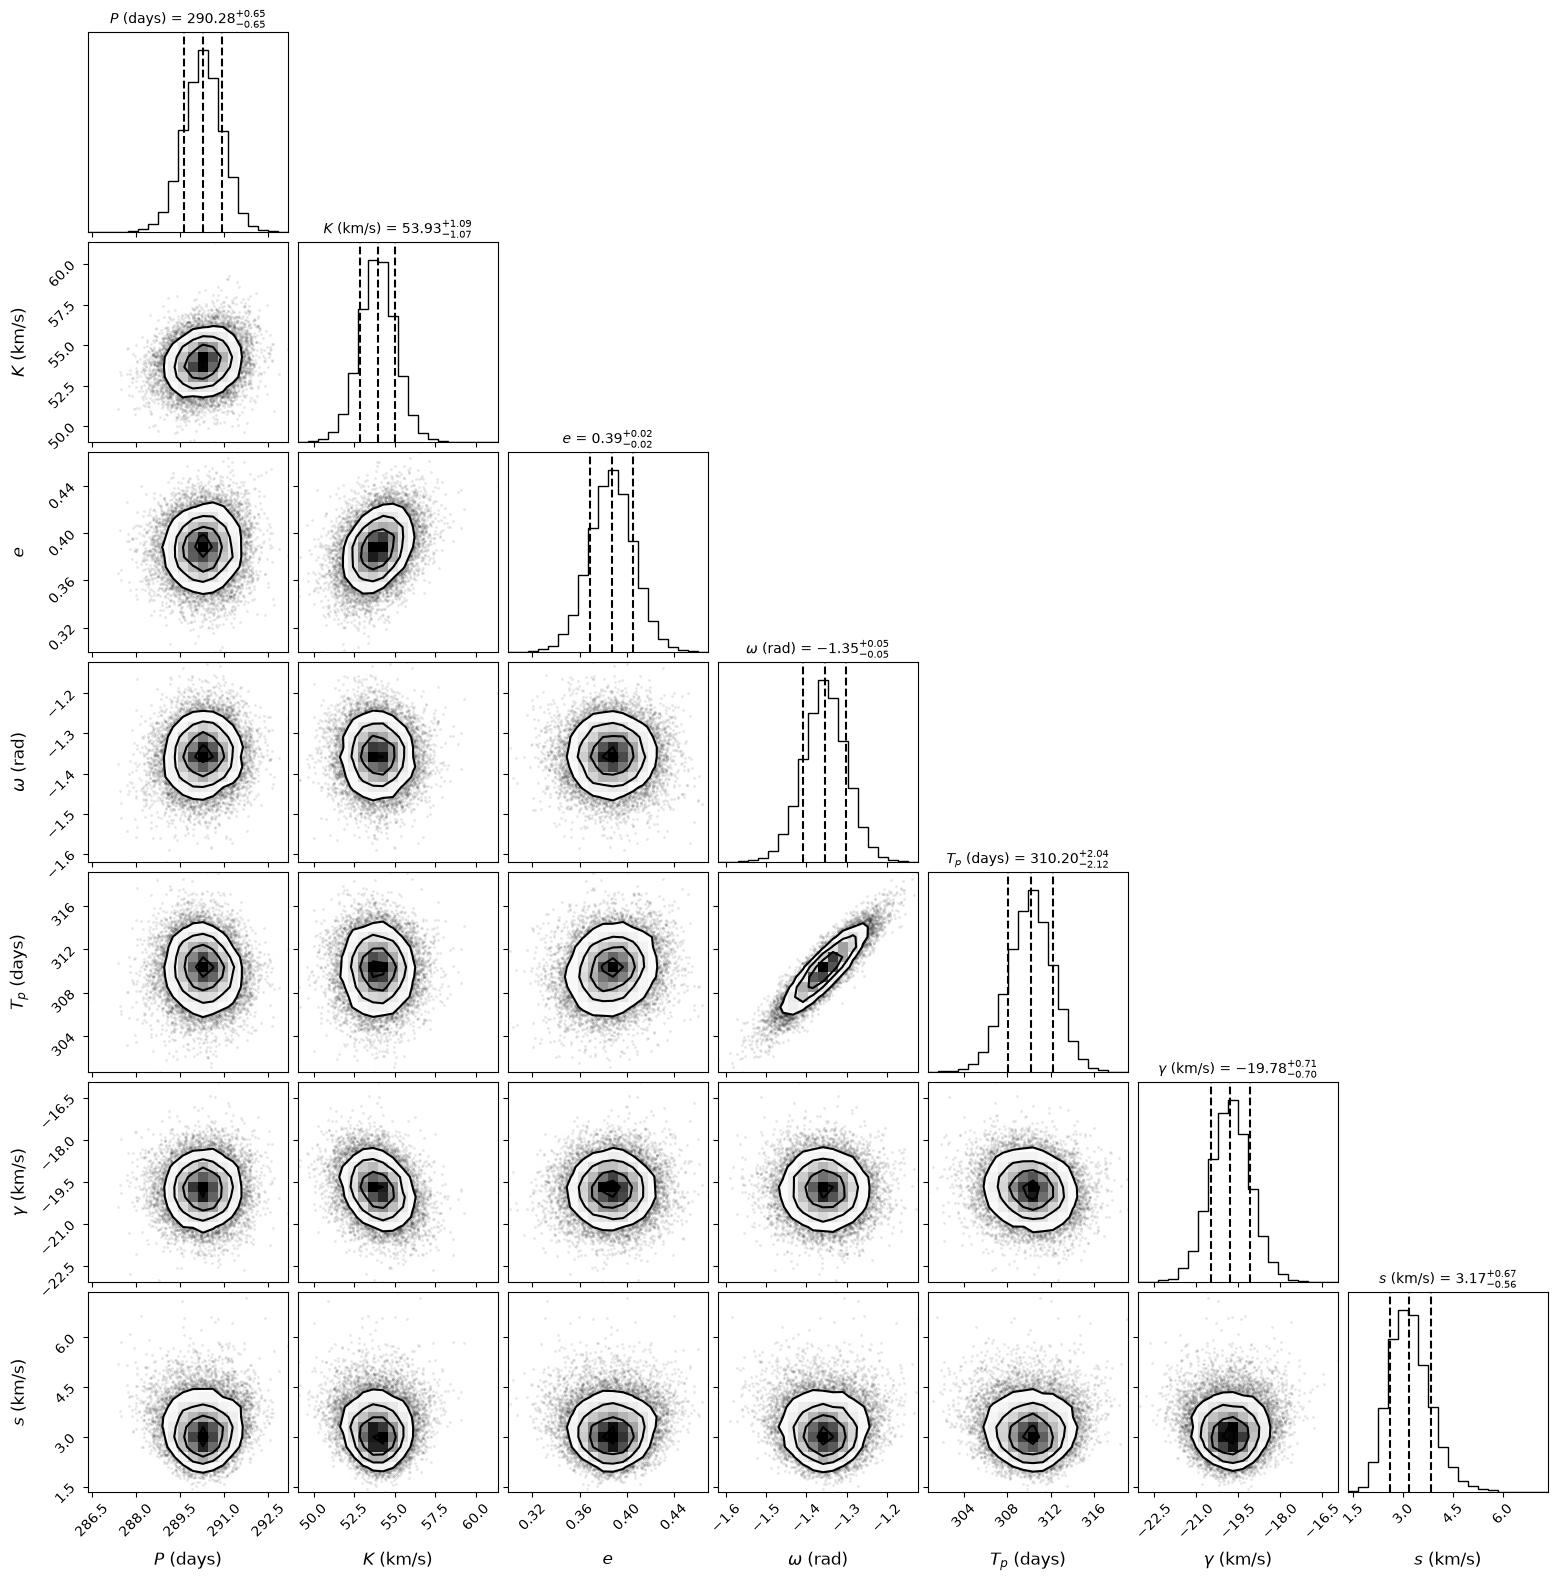

In [153]:
#Part 2.4
lnP, K, h, k, Tp, gamma, lns = flat_samples.T

P = np.exp(lnP)
e = h**2 + k**2
omega = np.arctan2(k, h)
s = np.exp(lns)

omega_ref = np.arctan2(best_theta[3], best_theta[2])
omega = omega_ref + (omega - omega_ref + np.pi) % (2*np.pi) - np.pi

samples_physical = np.column_stack([
    P, K, e, omega, Tp, gamma, s
])

labels = [
    r"$P$ (days)", r"$K$ (km/s)", r"$e$",
    r"$\omega$ (rad)", r"$T_p$ (days)",
    r"$\gamma$ (km/s)", r"$s$ (km/s)"
]

fig = corner.corner(
    samples_physical,
    labels=labels,
    quantiles=[0.16, 0.5, 0.84],
    show_titles=True,
    title_fmt=".2f",
    label_kwargs={"fontsize": 12},
    title_kwargs={"fontsize": 10}
)

plt.show()


Strong correlation between $\omega$ and Tp. this makes sense physically because both parameters affect the orbital phase of the radial velocity curve.

THere is also a positive correlation between K and e. The contours show that larger eccentricities tend to correspond to slightly larger velocity semi-amplitudes. Physically, eccentricity changes the shape of the radial velocity curve, while K controls its amplitude. Different combinations can reproduce similar observed velocity variations.

In [154]:
# Part 2.5
lnP, K, h, k, Tp, gamma, lns = flat_samples.T

P = np.exp(lnP)
e = h**2 + k**2
s = np.exp(lns)

fM = mass_function(P, K, e)

parameters = {
    "P (days)": P,
    "K (km/s)": K,
    "e": e,
    "gamma (km/s)": gamma,
    "s (km/s)": s,
    "f(M) (M_sun)": fM
}

print("Posterior estimates (median and 68% interval):\n")

for name, samples in parameters.items():
    q16, q50, q84 = np.percentile(samples, [16, 50, 84])

    lower = q50 - q16
    upper = q84 - q50

    print(f"{name:16s} = {q50:.4f} (+{upper:.4f} / -{lower:.4f})")


Posterior estimates (median and 68% interval):

P (days)         = 290.2771 (+0.6505 / -0.6483)
K (km/s)         = 53.9332 (+1.0904 / -1.0694)
e                = 0.3872 (+0.0185 / -0.0187)
gamma (km/s)     = -19.7803 (+0.7054 / -0.7029)
s (km/s)         = 3.1669 (+0.6667 / -0.5551)
f(M) (M_sun)     = 3.6960 (+0.2164 / -0.2064)


I calculated the mass function for each posterior sample rather than using the median parameters because f(M) depends nonlinearly on P, K, and e, and computing it sample by sample preserves their uncertainties and correlations.

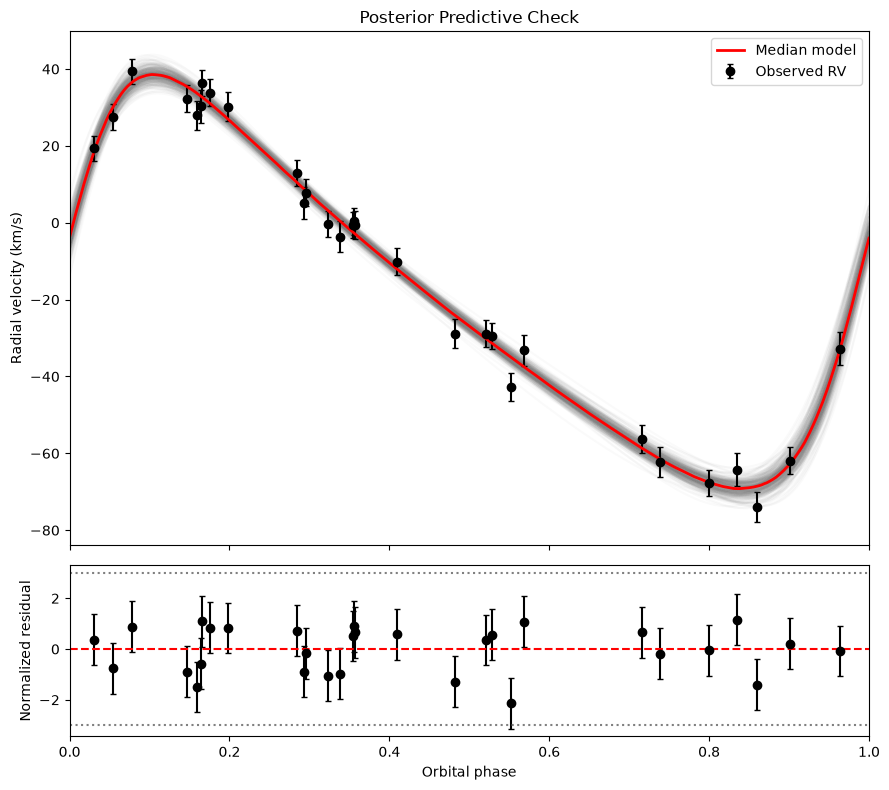

Median period = 290.277 days
Median jitter = 3.167 km/s
Mean normalized residual = -0.017
Std. normalized residual = 0.916
Residuals beyond 3 sigma = 0


In [155]:
# Part 2.6

P_med = np.median(np.exp(flat_samples[:, 0]))
s_med = np.median(np.exp(flat_samples[:, 6]))
Tp_med = np.median(flat_samples[:, 4])

phase = ((t - Tp_med) / P_med) % 1

indices = np.random.choice(len(flat_samples), 300, replace=False)
draws = flat_samples[indices]

phase_grid = np.linspace(0, 1, 500)
t_grid = Tp_med + phase_grid * P_med

predictions = []
model_curves = []

for lnP, K, h, k, Tp, gamma, lns in draws:
    P = np.exp(lnP)
    e = h**2 + k**2
    omega = np.arctan2(k, h)

    predictions.append(kepler_rv(t, P, K, e, omega, Tp, gamma))

    model_curves.append(kepler_rv(t_grid, P, K, e, omega, Tp, gamma))

predictions = np.array(predictions)
model_curves = np.array(model_curves)

rv_model = np.median(predictions, axis=0)

total_sig = np.sqrt(sig**2 + s_med**2)
residuals_norm = (rv - rv_model) / total_sig

fig, axes = plt.subplots(
    2, 1, figsize=(9, 8),
    sharex=True,
    gridspec_kw={"height_ratios": [3, 1]}
)

for curve in model_curves:
    axes[0].plot(phase_grid, curve, color="gray", alpha=0.04)

axes[0].errorbar(
    phase, rv, yerr=total_sig,
    fmt="o", color="black", capsize=2,
    label="Observed RV"
)

axes[0].plot(
    phase_grid, np.median(model_curves, axis=0),
    color="red", linewidth=2, label="Median model"
)

axes[0].set_ylabel("Radial velocity (km/s)")
axes[0].set_title("Posterior Predictive Check")
axes[0].legend()

axes[1].errorbar(
    phase, residuals_norm, yerr=np.ones_like(sig),
    fmt="o", color="black", capsize=2
)

axes[1].axhline(0, color="red", linestyle="--")
axes[1].axhline(3, color="gray", linestyle=":")
axes[1].axhline(-3, color="gray", linestyle=":")

axes[1].set_xlabel("Orbital phase")
axes[1].set_ylabel("Normalized residual")
axes[1].set_xlim(0, 1)

plt.tight_layout()
plt.show()

print(f"Median period = {P_med:.3f} days")
print(f"Median jitter = {s_med:.3f} km/s")
print(f"Mean normalized residual = {np.mean(residuals_norm):.3f}")
print(f"Std. normalized residual = {np.std(residuals_norm, ddof=1):.3f}")
print(f"Residuals beyond 3 sigma = {np.sum(np.abs(residuals_norm) > 3)}")


The residuals appear randomly scattered around zero without any clear systematic trend with orbital phase. Their standard deviation is close to 1, indicating that the remaining scatter is consistent with noise under the adopted uncertainty model. Therefore, the Keplerian model with the additional jitter term provides an adequate fit to the observations.

**FINAL ANSWER:** $P = $ 290.28 $\pm$ 0.65 d, $K = $ 53.93 $\pm$ 1.08 km/s, $e = $ 0.387 $\pm$ 0.019 , $\gamma = $ -19.78 $\pm$ 0.70 km/s, $s = $ 3.17 $\pm$ 0.67 km/s, $f(M) = $ 3.7 $\pm$ 0.22 $M_\odot$

**Black-hole candidate?** *one sentence*

Yes, the mass is > 3 solar $M_\odot$even with the uncertainties.

## Part 3: The referee report (35%)

The file `ai_solution.ipynb` in this directory is a complete, tidy, confident MCMC analysis of this exact
problem, produced by an AI assistant. It runs top to bottom without errors, the corner plot is handsome, and
the prose is fluent. It is also wrong, in at least **three** distinct, substantive ways (cosmetic nitpicks and
style don't count; "it used 24 walkers and I used 32" is not a finding).

Write a referee report:

1. **Identify** at least three substantive statistical errors.
2. **Demonstrate** each one quantitatively on *your* dataset: show, with a number or a plot, what the error
   does to the inference. For a sampler, "demonstrate" usually means running it the wrong way and the right
   way and comparing. A demonstration can come out negative: if an error turns out not to move *your*
   numbers, showing that, and saying what it would take for it to bite, is a valid finding.
3. **State** the correct treatment (you built it in Part 2).

Third time you have done this. You should be finding these in minutes now.


1. PERIOD PRIOR
AI periodogram peak = 298.188 d
Correct posterior median = 290.277 d
AI log-prior penalty at posterior median = -125.2

2. MISSING JITTER
Extra variance s^2 = 10.03 (km/s)^2
Without jitter: residual std = 2.110
With jitter:    residual std = 0.918
No-jitter optimization successful: True
P: no jitter = 289.997, correct = 290.277 d
K: no jitter = 54.442, correct = 53.933 km/s
e: no jitter = 0.3896, correct = 0.3872

3. MCMC CONVERGENCE
Correct maximum tau = 81.3
Required 50*tau = 4064 steps
AI run length = 1500 steps
AI length / correct max tau = 18.5
Period std, first 1500 steps = 0.6426 d
Period std, full posterior = 0.6649 d


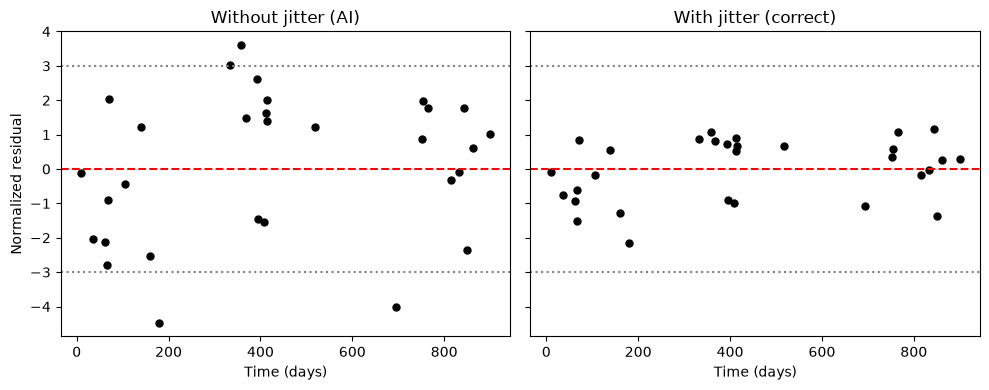

In [157]:
# Part 3: your work here
lnP, K, h, k, Tp, gamma, lns = flat_samples.T
P = np.exp(lnP)
e = h**2 + k**2
s = np.exp(lns)

med = np.median(flat_samples, axis=0)
P_med = np.median(P)
s_med = np.median(s)

model = kepler_rv(
    t, np.exp(med[0]), med[1],
    med[2]**2 + med[3]**2,
    np.arctan2(med[3], med[2]),
    med[4], med[5]
)

# 1. Tight, data-derived period prior
freq = np.linspace(1/600, 1/20, 20000)
power = LombScargle(t, rv, sig).power(freq)
P_peak = 1/freq[np.argmax(power)]

penalty = -0.5*((P_med - P_peak)/0.5)**2

print("1. PERIOD PRIOR")
print(f"AI periodogram peak = {P_peak:.3f} d")
print(f"Correct posterior median = {P_med:.3f} d")
print(f"AI log-prior penalty at posterior median = {penalty:.1f}")

# 2. Missing jitter
z_wrong = (rv - model)/sig
z_right = (rv - model)/np.sqrt(sig**2 + s_med**2)

print("\n2. MISSING JITTER")
print(f"Extra variance s^2 = {s_med**2:.2f} (km/s)^2")
print(f"Without jitter: residual std = {np.std(z_wrong, ddof=1):.3f}")
print(f"With jitter:    residual std = {np.std(z_right, ddof=1):.3f}")

def no_jitter_objective(x):
    theta = np.append(x, np.log(s_med))
    if not np.isfinite(log_prior(theta)):
        return 1e100

    lnP0, K0, h0, k0, Tp0, gamma0 = x
    m = kepler_rv(
        t, np.exp(lnP0), K0, h0**2+k0**2,
        np.arctan2(k0, h0), Tp0, gamma0
    )
    return 0.5*np.sum((rv-m)**2/sig**2)

sol = minimize(
    no_jitter_objective, best_theta[:6],
    method="Nelder-Mead",
    options={"maxiter": 15000}
)

print("No-jitter optimization successful:", sol.success)
print(f"P: no jitter = {np.exp(sol.x[0]):.3f}, correct = {P_med:.3f} d")
print(f"K: no jitter = {sol.x[1]:.3f}, correct = {np.median(K):.3f} km/s")
print(f"e: no jitter = {sol.x[2]**2+sol.x[3]**2:.4f}, correct = {np.median(e):.4f}")

# 3. Insufficient MCMC length
tau = sampler.get_autocorr_time()

short_chain = sampler.get_chain()[:1500]
short_P = np.exp(short_chain[100:, :, 0].ravel())

print("\n3. MCMC CONVERGENCE")
print(f"Correct maximum tau = {np.max(tau):.1f}")
print(f"Required 50*tau = {50*np.max(tau):.0f} steps")
print("AI run length = 1500 steps")
print(f"AI length / correct max tau = {1500/np.max(tau):.1f}")
print(f"Period std, first 1500 steps = {np.std(short_P):.4f} d")
print(f"Period std, full posterior = {np.std(P):.4f} d")

fig, ax = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

for a, z, title in zip(
    ax, [z_wrong, z_right],
    ["Without jitter (AI)", "With jitter (correct)"]
):
    a.scatter(t, z, color="black", s=25)
    a.axhline(0, color="red", linestyle="--")
    a.axhline(3, color="gray", linestyle=":")
    a.axhline(-3, color="gray", linestyle=":")
    a.set_xlabel("Time (days)")
    a.set_title(title)

ax[0].set_ylabel("Normalized residual")
plt.tight_layout()
plt.show()


**REFEREE REPORT:**

*your report goes here*

1. An unjustifiably narrow period prior: It imposes a Gaussian prior of width 0.5 days, centered on a period estimated from the same observations. Correct treatment: Use the periodogram to identify candidate starting periods, but use a broad, justified period prior and let the Keplerian likelihood determine the posterior. Using the AI's frequency grid, the periodogram peak was 298.188 days, while my posterior analysis found P=290.277 days. The AI's Gaussian prior imposes a log-prior penalty of −125.2 at my preferred period, strongly suppressing that solution even though it fits the radial velocity observations better.

2. Missing stellar jitter: The AI uses only the pipeline uncertainties $\sigma_i$, even though the likelihood must include $\sigma_i^2+s^2$. Correct treatment: Take the jitter into account when fitting a model. Especially with likelihood, use the log variance term for $\ln L$. My posterior analysis found a median jitter of s=3.167 km/s. Without jitter, the normalized residuals had a standard deviation of 2.110, compared with 0.918 when jitter was included.

3. An inadequate convergence test: It runs only 1,500 MCMC steps, discards a fixed 100 steps, and treats a reasonable acceptance fraction as proof of convergence. Correct treatment: Run sufficiently long chains, estimate autocorrelation times without disabling the reliability check, examine trace plots, and choose burn-in and thinning based on the measured autocorrelation times. My  sampled chain in part 2 had a maximum integrated autocorrelation time of 81.3 steps, requiring approximately 4,064 steps. The AI's 1,500 step chain would span only about 18.5 times this autocorrelation scale, although its own autocorrelation time could differ.

   I compared the first 1,500 steps of my chain with the full posterior. The period standard deviation was 0.6426 days for the short chain and 0.6649 days for the full chain, a difference of approximately 3.4%. Thus, shortening the chain did not substantially affect my period uncertainty in this test. However, this does not establish convergence of the AI's sampler, especially given its different likelihood and prior.

## Part 4: AI-use appendix and verification plan (10%)

1. **AI use**: which tools did you use, for what, what did they get wrong, and how did you catch it? Honesty
   is graded; "I didn't use any" is fine if true.
2. **Reflection (new from this lab on, two or three sentences)**: what did you use AI for in this lab, and
   what would have gone wrong in your answer if you had not checked its output? Name the specific thing, not
   "it could have made a mistake".
3. **Verification plan**: the checks you ran before trusting your Part 2 numbers, and what failure would have
   looked like for each. One you should seriously consider: generate a synthetic RV curve with parameters
   you choose, at *your* epochs, run your whole Part 2 pipeline on it, and see whether the 68% intervals
   contain what you put in. With seven parameters and one realisation, expect about five of seven inside
   their 68% intervals; one pull of 2.5σ is not a failure by itself. Failure looks systematic: the same
   parameter off in the same direction every time, or an interval that never contains the truth.


**AI-USE APPENDIX:**

ChatGPT
Prompts:


- Writing print statements and plotting code

- Writing tests, and making functions

- Used ai to help code the tests

- Helping interpret emcee and sampling the posterior

- Check my results and help identify anything that needs further testing or explanation.


I verified all results by running the code, performing the tests, and checking that the outputs were consistent with the model assumptions.
**REFLECTION:**

The main risk of my use of AI in this lab would have been in part 2 had I not been checking its output. First, it suggested to make the Tp prior (0,P) contrasting the warning in the prompt and leading to divergence in the walkers, which I was able to catch. It was also not initially using least-squares to find better initial fits before optimizing the full likelihood.
**VERIFICATION PLAN:**

*your plan goes here*

1. Synthetic data recovery test

I would generate synthetic radial velocities using kepler_rv with known orbital parameters, evaluated at my actual observing epochs. I would add Gaussian noise using the total uncertainty $\sqrt{\sigma_i^2+s^2}$, then run the same optimization and MCMC pipeline from Part 2 on the synthetic dataset.

I would compare the recovered posterior medians and 68% credible intervals with the input parameters. A single parameter falling outside its interval would not necessarily indicate a problem. Failure would look like repeated systematic biases or intervals consistently missing the true values across several synthetic realizations.

5 of the 7 parameters were recovered within their 68% intervals. $\omega$ and periastron time, which we have shown to be strongly correlated, narrowly missed their intervals. Gamma had the largest deviation relative to its reported uncertainty (~2.3 sigma). The chain length was satisfied, 

2. MCMC convergence check

I checked the integrated autocorrelation time for all seven parameters and examined the walker trace plots and acceptance fractions. My final run used 64 walkers for 10,000 steps, with a maximum autocorrelation time of approximately 81 steps, satisfying the (50\tau) criterion. The chains appeared stationary and well mixed, with no unusually low acceptance fractions.

Failure would look like walkers remaining trapped in separate regions, drifting traces, very low acceptance fractions, or a chain too short relative to its autocorrelation time. I encountered this in an earlier run, which led to improving the maximum-likelihood initialization using least squares before rerunning MCMC.

3. Posterior predictive check

I drew 300 orbital curves from the posterior and compared them with the measured radial velocities. I also examined the residuals normalized by the total uncertainty, including jitter. The normalized residuals had a mean of −0.017 and a standard deviation of 0.916, with no points beyond (3\sigma).

Failure would look like systematic patterns in the residuals, particularly with orbital phase, or a residual scatter substantially larger than expected from the adopted noise model.

Chain length: 10000
50 * max(tau): 4122.7
Length criterion met: True

Synthetic data recovery (68% intervals):
Parameter       Truth     Median        16%        84%   Covered
P             293.000    293.055    292.393    293.751      True
K              55.000     55.661     54.341     56.985      True
e               0.350      0.369      0.346      0.392      True
omega          -1.151     -1.339     -1.398     -1.277     False
Tp            320.317    313.988    311.821    316.220     False
gamma         -18.000    -18.283    -19.098    -17.476      True
s               3.500      3.733      3.133      4.458      True

Parameters recovered within 68% intervals: 5/7


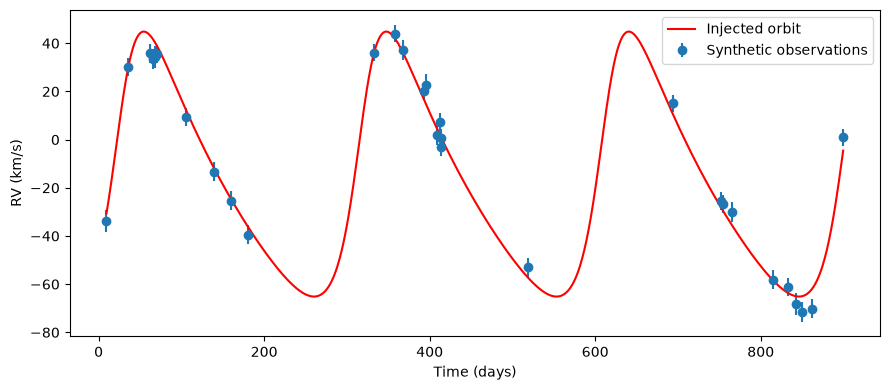

In [160]:
#Synthetic data recovery test

rng = np.random.default_rng(47)

# Choose known input parameters
P_true = 293.0
K_true = 55.0
e_true = 0.35
omega_true = np.arctan2(best_theta[3], best_theta[2]) + 0.2
Tp_true = best_theta[4] + 10
gamma_true = -18.0
s_true = 3.5

# Generate synthetic RVs at our actual epochs
rv_true = kepler_rv(
    t, P_true, K_true, e_true,
    omega_true, Tp_true, gamma_true
)

sig_total = np.sqrt(sig**2 + s_true**2)
rv_syn = rv_true + rng.normal(0, sig_total)

# Synthetic log-posterior: same priors and likelihood as Part 2
def log_prob_syn(theta):
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf

    lnP, K, h, k, Tp, gamma, lns = theta
    model = kepler_rv(
        t, np.exp(lnP), K, h**2+k**2,
        np.arctan2(k, h), Tp, gamma
    )
    var = sig**2 + np.exp(2*lns)

    return lp - 0.5*np.sum(
        (rv_syn-model)**2/var + np.log(2*np.pi*var)
    )

# First find an orbital fit using least-squares
def residuals_syn(x):
    lnP, K, e, omega, Tp, gamma = x
    model = kepler_rv(t, np.exp(lnP), K, e, omega, Tp, gamma)
    return (rv_syn-model)/sig

x0 = [
    np.log(np.exp(best_theta[0])), best_theta[1],
    best_theta[2]**2 + best_theta[3]**2,
    np.arctan2(best_theta[3], best_theta[2]),
    best_theta[4], best_theta[5]
]

bounds = (
    [np.log(50), 0.01, 0, -np.inf, Tp_min, -200],
    [np.log(2000), 199, 0.99, np.inf, Tp_max, 200]
)

fit = least_squares(residuals_syn, x0, bounds=bounds)

lnP0, K0, e0, w0, Tp0, gamma0 = fit.x
theta0 = np.array([
    lnP0, K0,
    np.sqrt(e0)*np.cos(w0),
    np.sqrt(e0)*np.sin(w0),
    Tp0, gamma0, np.log(s_true)
])

# Refine with the full jitter-inclusive likelihood
sol = minimize(
    lambda x: -log_prob_syn(x) if np.isfinite(log_prob_syn(x)) else 1e100,
    theta0, method="Nelder-Mead",
    options={"maxiter": 10000}
)

theta_start = sol.x if np.isfinite(log_prob_syn(sol.x)) else theta0

# Initialize and run MCMC
scale = np.array([1e-3, 0.1, 1e-3, 1e-3, 0.1, 0.1, 1e-2])
pos_syn = []

while len(pos_syn) < 64:
    trial = theta_start + scale*rng.normal(size=7)
    if np.isfinite(log_prob_syn(trial)):
        pos_syn.append(trial)

sampler_syn = emcee.EnsembleSampler(64, 7, log_prob_syn)
sampler_syn.run_mcmc(np.array(pos_syn), 10000, progress=False)

# Check autocorrelation times
tau_syn = sampler_syn.get_autocorr_time(tol=0)
N_syn = sampler_syn.get_chain().shape[0]

print(f"Chain length: {N_syn}")
print(f"50 * max(tau): {50*np.max(tau_syn):.1f}")
print("Length criterion met:", N_syn > 50*np.max(tau_syn))

burn_syn = int(np.ceil(3*np.max(tau_syn)))
thin_syn = max(1, int(0.5*np.min(tau_syn)))

samples_syn = sampler_syn.get_chain(
    discard=burn_syn, thin=thin_syn, flat=True
)

# Convert samples to physical parameters
lnP, K, h, k, Tp, gamma, lns = samples_syn.T

omega = np.arctan2(k, h)
omega = omega_true + (omega-omega_true+np.pi) % (2*np.pi) - np.pi

recovered = [
    np.exp(lnP), K, h**2+k**2,
    omega, Tp, gamma, np.exp(lns)
]

truths = [
    P_true, K_true, e_true,
    omega_true, Tp_true, gamma_true, s_true
]

names = ["P", "K", "e", "omega", "Tp", "gamma", "s"]

print("\nSynthetic data recovery (68% intervals):")
print(f"{'Parameter':10s} {'Truth':>10s} {'Median':>10s} "
      f"{'16%':>10s} {'84%':>10s} {'Covered':>9s}")

covered = 0

for name, truth, values in zip(names, truths, recovered):
    q16, q50, q84 = np.percentile(values, [16, 50, 84])
    inside = q16 <= truth <= q84
    covered += inside

    print(f"{name:10s} {truth:10.3f} {q50:10.3f} "
          f"{q16:10.3f} {q84:10.3f} {str(inside):>9s}")

print(f"\nParameters recovered within 68% intervals: {covered}/7")

# Plot synthetic observations and recovered orbit
t_grid = np.linspace(t.min(), t.max(), 1000)

plt.figure(figsize=(9, 4))
plt.errorbar(t, rv_syn, yerr=sig_total,
             fmt="o", label="Synthetic observations")
plt.plot(t_grid, kepler_rv(
    t_grid, P_true, K_true, e_true,
    omega_true, Tp_true, gamma_true
), label="Injected orbit", color="red")

plt.xlabel("Time (days)")
plt.ylabel("RV (km/s)")
plt.legend()
plt.tight_layout()
plt.show()
